In [ ]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------


# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

Setup complete. NumPy 2.0.2
scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [ ]:
print(tensor)

[[[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]]


In [ ]:

# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())  #gives one dimensiaonal array of A

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [ ]:
##LAB EXERCISE
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
# YOUR CODE HERE
print(T.ndim)
print(T.shape)
# 2. T + T
# YOUR CODE HERE
print(T+T)
# 3. Transpose (print .T.shape) and reshape to (2, 6)
# YOUR CODE HERE
print(T.T)
print(T.shape)
print(T.reshape(2,6))
print(T.shape)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
2
(3, 4)
[[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
(3, 4)
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
(3, 4)


2. Dot & cross products, and norms

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))


a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


LAB EXERCISE 2 — L1/L2 norms + cosine similarity on 3 vector pairs
Three vector pairs are provided in pairs. For each pair (u, v):

Print the L1 and L2 norm of u.
Print the cosine similarity between u and v (reuse the cosine function above).
Which pair is the most similar? Note it in a comment.

In [ ]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    L1=la.norm(u,1)
    L2=la.norm(u)
    print(L1,L2)
    # 2. cosine similarity of u and v
    print(cosine(u,v))
    pass
# 3. Most similar pair = [1, 0, 1] [1, 0, 1]

2.0 1.4142135623730951
0.9999999999999998
6.0 3.7416573867739413
0.7142857142857143
2.0 2.0
0.0


3. Matrix operations & special matrices

In [ ]:

# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [ ]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
print('inverse(M):\n', la.inv(M))
print('trace(M) = sum of diagonal:', np.trace(M))

# 2. M @ inv(M) == I ?
print(np.allclose(M @ la.inv(M), I))

# 3. Is M symmetric? Is P orthogonal?
print('M symmetric?', np.allclose(M, M.T))



inverse(M):
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
trace(M) = sum of diagonal: 7.0
True
M symmetric? True


4. Transformations: rotation & scaling

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


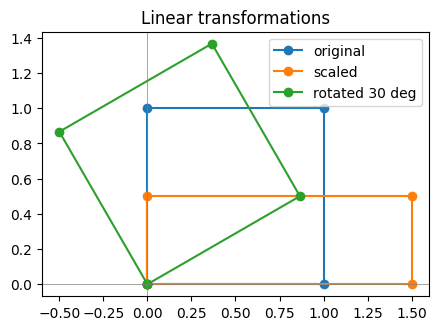

In [ ]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

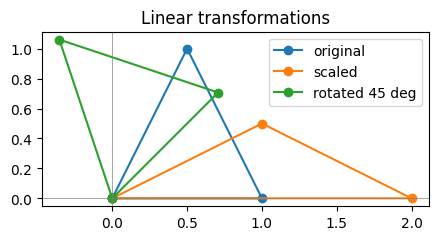

In [ ]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2, 0.0],
              [0.0, 0.5]])

# 2. Rotation matrix (45 degrees)
t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])
scaled  = S @ tri      # apply scaling
rotated = R @ tri      # apply rotation
# 3. Apply both and plot original vs transformed

def close_loop(pts):
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(tri),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 45 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

5. Eigenvalues & eigenvectors
For a matrix A, an eigenvector v is a direction that A only stretches (never rotates), and the eigenvalue lambda is how much it stretches it: A v = lambda v.

In [ ]:

# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]
lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [ ]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
vals, vecs = la.eig(C)     # vals = eigenvalues, vecs columns = eigenvectors


# 2. print eigenvalues
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

# 3. verify A v = lambda v for the first eigenvector
v = vecs[:, 0]
lhs = C @ v
rhs = vals[0] * v
print("\nFirst Eigenvector:")
print(v)

print("\nC @ v =")
print(lhs)

print("\nλ * v =")
print(rhs)

print("\nVerification:", np.allclose(lhs, rhs))


Eigenvalues  (lambda): [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]

First Eigenvector:
[0.707 0.707]

C @ v =
[3.536 3.536]

λ * v =
[3.536 3.536]

Verification: True


6. Rank, solving systems & cosine similarity

In [ ]:

A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])
x = la.solve(A2, b2)
print('Solution x:', x)
print('Rank of A2:', la.matrix_rank(A2), '-> < 3, so rows are dependent')
print('cosine(cat, dog):', round(cosine(cat, dog), 3))   #similar
print('cosine(cat, car):', round(cosine(cat, car), 3))

Solution x: [1. 2.]
Rank of A2: 2 -> < 3, so rows are dependent
cosine(cat, dog): 0.995
cosine(cat, car): 0.293


##CALCULUS in ML

In [ ]:
import numpy as np
import sympy as sp

x, y = sp.symbols('x y')      # symbolic variables we'll reuse
sp.init_printing()            # pretty-print symbolic math
np.random.seed(42)
print('Setup complete. SymPy', sp.__version__, '| NumPy', np.__version__)

Setup complete. SymPy 1.14.0 | NumPy 2.0.2


In [ ]:

# The derivative is the slope: how much f changes for a tiny step h
def f(x):
    return x**2

h = 1e-6
slope_at_3 = (f(3 + h) - f(3)) / h
print('Numerical f\'(3):', round(slope_at_3, 4), ' (exact = 6)')

Numerical f'(3): 6.0  (exact = 6)


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. SYMBOLIC DERIVATIVE (SymPy)
# -----------------------------------------------------------

expr = x**2
deriv = sp.diff(expr, x)          # differentiate w.r.t. x
print('d/dx (x**2) =', deriv)     # 2*x

# Evaluate the symbolic derivative at x = 3
print('Symbolic f\'(3) =', deriv.subs(x, 3))

d/dx (x**2) = 2*x
Symbolic f'(3) = 6


In [ ]:

def g(x):
    return x**3 + 2*x

# 1. Numerical derivative at x = 2
h = 1e-6
numerical_derivative = (g(2 + h) - g(2)) / h

print("Numerical derivative at x=2:", numerical_derivative)

expr = x**3 + 2*x
deriv = sp.diff(expr, x)
print( deriv)

# Evaluate the symbolic derivative at x = 2
print('Symbolic f\'(2) =', deriv.subs(x, 2))


Numerical derivative at x=2: 14.000006002490295
3*x**2 + 2
Symbolic f'(2) = 14


2. Partial derivatives & the gradient

In [ ]:

h2 = x**2 * y + sp.sin(y)

# 1. dh/dx and dh/dy
print('dh/dx:', sp.diff(h2, x))
print('dh/dy:', sp.diff(h2, y))

# 2. Assemble the gradient list
gradient = [sp.diff(h2, var) for var in [x, y]]
print('Gradient:', gradient)

# 3. Evaluate at (x=2, y=0)  -> hint: .subs({x: 2, y: 0})
grad_at = [g.subs({x: 2, y: 0}) for g in gradient]
print('grad f at (2, 0) =', grad_at)

dh/dx: 2*x*y
dh/dy: x**2 + cos(y)
Gradient: [2*x*y, x**2 + cos(y)]
grad f at (2, 0) = [0, 5]


3. The chain rule

In [ ]:

import sympy as sp

#x = sp.Symbol('x')

# 1. By hand (Chain Rule)
by_hand = sp.exp(x**2 + 1) * (2*x)

# 2. With sp.diff
by_sympy = sp.diff(sp.exp(x**2 + 1), x)

# 3. Confirm they match
print("By hand :", by_hand)
print("By SymPy:", by_sympy)
print("Match?  ", sp.simplify(by_hand - by_sympy) == 0)

By hand : 2*x*exp(x**2 + 1)
By SymPy: 2*x*exp(x**2 + 1)
Match?   True


In [ ]:
Xb = np.random.randn(6, 4)
Yb = np.random.randn(6, 1)
Wa = np.random.randn(4, 8) * 0.1     # input -> hidden
Wb = np.random.randn(8, 1) * 0.1     # hidden -> output

# 1. Forward pass: z1, h = ReLU(z1), y_hat, loss

z1 = Xb @ Wa                 # linear layer 1
h  = np.maximum(0, z1)      # ReLU activation
y_hat = h @ Wb
loss = ((y_hat - Yb) ** 2).mean()
print('Initial loss:', round(loss, 4))


# 2. Backward pass: dy, dWb, dh, dz1, dWa
# YOUR CODE HERE
dy   = 2 * (y_hat - Yb) / Yb.size      # d loss / d y_hat
dWb  = h.T @ dy                      # d loss / d W2
dh   = dy @ Wb.T                     # d loss / d h
dz1  = dh * (z1 > 0)                 # ReLU gradient (1 where z1>0 else 0)
dWa  = Xb.T @ dz1                     # d loss / d W1
print('dW1 shape:', dWa.shape, '(matches Wa)')
print('dW2 shape:', dWb.shape, '(matches Wb)')

# 3. One step with lr = 0.05; print loss before and after
lr = 0.05
Wa -= lr * dWa               # step downhill
Wb -= lr * dWb

# Recompute the loss after the update
h_new = np.maximum(0, Xb @ Wa)
loss_new = ((h_new @ Wb - Yb) ** 2).mean()
print('Loss before:', round(loss, 4))
print('Loss after :', round(loss_new, 4), '-> should be lower')


Initial loss: 0.4049
dW1 shape: (4, 8) (matches Wa)
dW2 shape: (8, 1) (matches Wb)
Loss before: 0.4049
Loss after : 0.4032 -> should be lower


In [ ]:
x, y = sp.symbols('x y')

f = x**4 + y**2

H = sp.hessian(f, (x, y))

print("Hessian:")
print(H)



xv = 0.0
lr = 0.1

for step in range(20):
    grad = 2 * (xv - 7)
    xv = xv - lr * grad

print("Final x:", xv)


Hessian:
Matrix([[12*x**2, 0], [0, 2]])
Final x: 6.91929549467752


####NumPy_Exercise

In [ ]:
import numpy as np
print("--- Intermediate NumPy Exercise ---")
print("Complete each task by writing the requested NumPy code.")
print("-----------------------------------")

# Task 1: Array Creation Shortcuts
print("\n--- Task 1: Array Creation Shortcuts ---")
# 1.1 Create a 1D array named 'arr1_1' with numbers from 0 to 99 (inclusive) using arange.
# 1.2 Create a 3x3 array named 'arr1_2' filled with ones.
# 1.3 Create a 2x4 array named 'arr1_3' filled with the number 7.
# 1.4 Create a 5x5 array named 'arr1_4' with random integers between 10 and 50 (inclusive).

# Your code for Task 1 here:
arr1_1=np.arange(100)
arr1_2=np.ones((3,3))
arr1_3=np.full((2,4),7)
arr1_4=np.random.randint(10,51,(5,5))

print("arr1_1 (first 10 elements):", arr1_1[:10])
print("arr1_2:\n", arr1_2)
print("arr1_3:\n", arr1_3)
print("arr1_4 (first 2 rows):\n", arr1_4[:2])
# Task 2: Indexing and Slicing with Arrays
print("\n--- Task 2: Indexing and Slicing with Arrays ---")
data = np.array([[10, 20, 30, 40],
                 [50, 60, 70, 80],
                 [90, 100, 110, 120],
                 [130, 140, 150, 160]])

# 2.1 Extract the element at row 2, column 3 (0-indexed). Store it in 'val2_1'.
# 2.2 Extract the first row. Store it in 'row2_2'.
# 2.3 Extract the last column. Store it in 'col2_3'.
# 2.4 Extract the sub-array consisting of rows 1 and 2, and columns 0 and 1. Store it in 'sub_arr2_4'.
# 2.5 Using boolean indexing, select all elements in 'data' that are greater than 100. Store them in 'filtered_elements2_5'.

# Your code for Task 2 here:
val2_1=data[2,3]
row2_2=data[0]
col2_3=data[:,3]
sub_arr2_4=data[1:3,0:2]
filtered_elements2_5=data[data>100]

# Task 3: Conditional Operations
print("\n--- Task 3: Conditional Operations ---")
arr3_1 = np.random.randint(1, 21, size=(4, 5)) # Random 4x5 array with values 1 to 20

# 3.1 Create a new array 'arr3_2' where elements in 'arr3_1' less than 10 are replaced with 0,
#     and elements greater than or equal to 10 remain unchanged.
# 3.2 Count how many elements in 'arr3_1' are even. Store the count in 'even_count3_3'.

# Your code for Task 3 here:
arr3_2=np.where(arr3_1<10,0,arr3_1)
even_count3_3=np.count_nonzero(arr3_1%2==0)
# Task 4: Aggregation Functions
print("\n--- Task 4: Aggregation Functions ---")
arr4_1 = np.array([[10, 5, 12],
                   [3, 8, 15],
                   [20, 7, 4]])

# 4.1 Calculate the sum of all elements in 'arr4_1'. Store it in 'sum4_1'.
# 4.2 Calculate the mean of each column. Store it in 'mean_cols4_2'.
# 4.3 Find the maximum value in each row. Store it in 'max_rows4_3'.
# 4.4 Calculate the standard deviation of the entire array. Store it in 'std4_4'.

# Your code for Task 4 here:
sum4_1=np.sum(arr4_1)
mean_cols4_2=np.mean(arr4_1,axis=0)
max_rows4_3=np.max(arr4_1,axis=1)
std4_4=np.std(arr4_1)
# Task 5: Reshaping and Flattening
print("\n--- Task 5: Reshaping and Flattening ---")
arr5_1 = np.arange(24) # 1D array from 0 to 23

# 5.1 Reshape 'arr5_1' into a 4x6 2D array. Store it in 'reshaped_arr5_2'.
# 5.2 Reshape 'arr5_1' into a 2x3x4 3D array. Store it in 'reshaped_arr5_3'.
# 5.3 Flatten 'reshaped_arr5_2' back into a 1D array. Store it in 'flattened_arr5_4'.
#     Use both `.ravel()` and `.flatten()` to see if there's a difference (though not visible in output).

# Your code for Task 5 here:
reshaped_arr5_2=arr5_1.reshape((4,6))
reshaped_arr5_3=arr5_1.reshape((2,3,4))
flattened_arr5_4=reshaped_arr5_2.ravel()
# Task 6: Broadcasting
print("\n--- Task 6: Broadcasting ---")
arr6_1 = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
scalar = 10
vector = np.array([100, 200, 300])

# 6.1 Add the 'scalar' to every element of 'arr6_1'. Store it in 'result6_1'.
# 6.2 Add the 'vector' to each row of 'arr6_1'. Store it in 'result6_2'.

# Your code for Task 6 here:
result6_1=arr6_1+scalar
result6_2=arr6_1+vector
# Task 7: Copying vs. Viewing Arrays
print("\n--- Task 7: Copying vs. Viewing Arrays ---")
original_arr7 = np.array([1, 2, 3, 4, 5])

# 7.1 Create a 'view' of 'original_arr7' named 'view_arr7' by slicing the entire array.
#     Modify the first element of 'view_arr7' to 99.
#     Observe how 'original_arr7' changes.
# 7.2 Create a 'copy' of 'original_arr7' named 'copy_arr7' using `.copy()`.
#     Modify the last element of 'copy_arr7' to 0.
#     Observe how 'original_arr7' remains unchanged.

# Your code for Task 7 here:
view_arr7=original_arr7[:]
view_arr7[0]=99
print(original_arr7)

copy_arr7=original_arr7.copy()
copy_arr7[-1]=0
print(original_arr7)
# Task 8: Stacking and Splitting Arrays
print("\n--- Task 8: Stacking and Splitting Arrays ---")
arr8_a = np.array([[1, 2], [3, 4]])
arr8_b = np.array([[5, 6], [7, 8]])
arr8_c = np.array([[9, 10]])

# 8.1 Vertically stack 'arr8_a' and 'arr8_b'. Store it in 'vstack_arr8_1'.
# 8.2 Horizontally stack 'arr8_a' and 'arr8_b'. Store it in 'hstack_arr8_2'.
# 8.3 Vertically stack 'vstack_arr8_1' and 'arr8_c'. Store it in 'combined_arr8_3'.
# 8.4 Split 'combined_arr8_3' into 3 equal parts (rows). Store them in 'part1', 'part2', 'part3'.

# Your code for Task 8 here:
vstack_arr8_1=np.vstack((arr8_a,arr8_b))
hstack_arr8_2=np.hstack((arr8_a,arr8_b))
combined_arr8_3=np.vstack((vstack_arr8_1,arr8_c))
part1,part2,part3=np.array_split(combined_arr8_3,3)
# Task 9: Sorting and Searching
print("\n--- Task 9: Sorting and Searching ---")
arr9_1 = np.array([5, 2, 8, 1, 9, 4, 7, 3, 6])
arr9_2d = np.array([[30, 20, 10],
                    [60, 50, 40],
                    [90, 80, 70]])

# 9.1 Sort 'arr9_1' in ascending order. Store it in 'sorted_arr9_1'.
# 9.2 Sort 'arr9_2d' along columns (i.e., each column sorted independently). Store it in 'sorted_cols9_2'.
# 9.3 Find the indices where the value 9 is present in 'arr9_1'. Store it in 'idx9_3'. (Hint: use np.where)
# 9.4 Find the index of the maximum value in 'arr9_1'. Store it in 'max_idx9_4'.

# Your code for Task 9 here:
sorted_arr9_1=np.sort(arr9_1)
sorted_cols9_2=np.sort(arr9_2d,axis=0)
idx9_3=np.where(arr9_1==9)
max_idx9_4=np.argmax(arr9_1)


--- Intermediate NumPy Exercise ---
Complete each task by writing the requested NumPy code.
-----------------------------------

--- Task 1: Array Creation Shortcuts ---
arr1_1 (first 10 elements): [0 1 2 3 4 5 6 7 8 9]
arr1_2:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
arr1_3:
 [[7 7 7 7]
 [7 7 7 7]]
arr1_4 (first 2 rows):
 [[37 32 46 41 42]
 [10 28 11 35 41]]

--- Task 2: Indexing and Slicing with Arrays ---

--- Task 3: Conditional Operations ---

--- Task 4: Aggregation Functions ---

--- Task 5: Reshaping and Flattening ---

--- Task 6: Broadcasting ---

--- Task 7: Copying vs. Viewing Arrays ---
[99  2  3  4  5]
[99  2  3  4  5]

--- Task 8: Stacking and Splitting Arrays ---

--- Task 9: Sorting and Searching ---


###**PYTHON PART2 LAB EXERCISES**

In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')   # nicer default plot styling
np.random.seed(42)                 # reproducible results
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)

Setup complete. NumPy 2.0.2 | Pandas 2.2.2


In [ ]:
# Given data
M = np.arange(1, 13).reshape(3, 4)   # shape (3, 4)
N = np.arange(1, 9).reshape(4, 2)    # shape (4, 2)
print('M:\n', M)
print('N:\n', N)

# 1. Matrix product M @ N
print('Matrix product ', M @ N)

# 2. Column-wise sum (axis=0) and row-wise mean (axis=1) of M
print('Column-wise sum of M:', np.sum(M, axis=0))
print('Row-wise mean of M:', np.mean(M, axis=1))

# 3. Index of the max value in each row of M (hint: argmax with axis=1)
print('Index of the max value in each row of M:', np.argmax(M, axis=1))


M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
Matrix product  [[ 50  60]
 [114 140]
 [178 220]]
Column-wise sum of M: [15 18 21 24]
Row-wise mean of M: [ 2.5  6.5 10.5]
Index of the max value in each row of M: [3 3 3]


In [ ]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
lab = sns.load_dataset('titanic')   # fresh copy to work on

# 1. Count missing values in 'embarked'
print('Missing values in embarked:', lab['embarked'].isnull().sum())

# 2. Fill missing 'embarked' with the mode (hint: lab['embarked'].mode()[0])
lab['embarked'].fillna(lab['embarked'].mode()[0], inplace=True)

#

# 3. Mean fare grouped by 'sex'
print('Mean fare grouped by sex:\n', lab.groupby('sex')['fare'].mean())



Missing values in embarked: 2
Mean fare grouped by sex:
 sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


/tmp/ipykernel_1144/3148462170.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lab['embarked'].fillna(lab['embarked'].mode()[0], inplace=True)


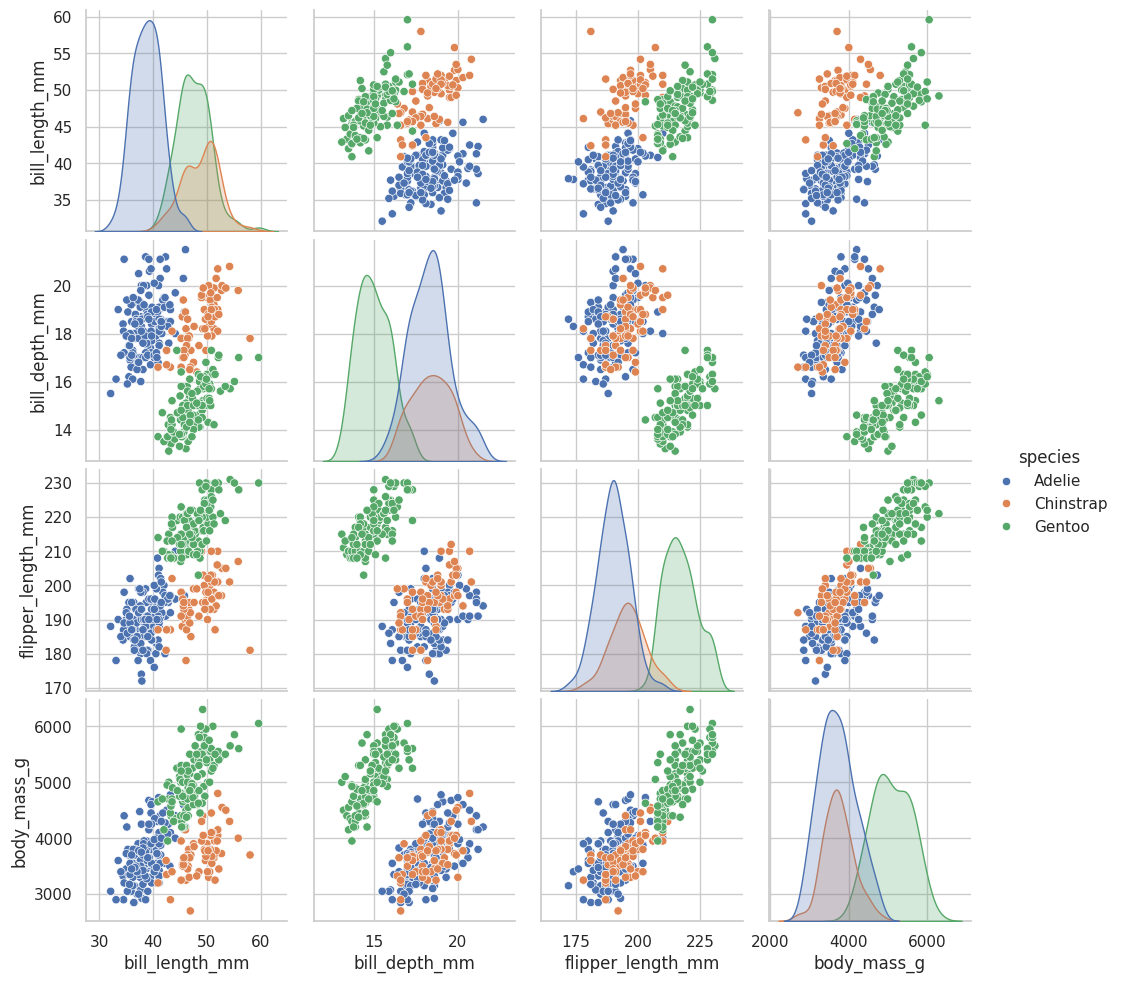

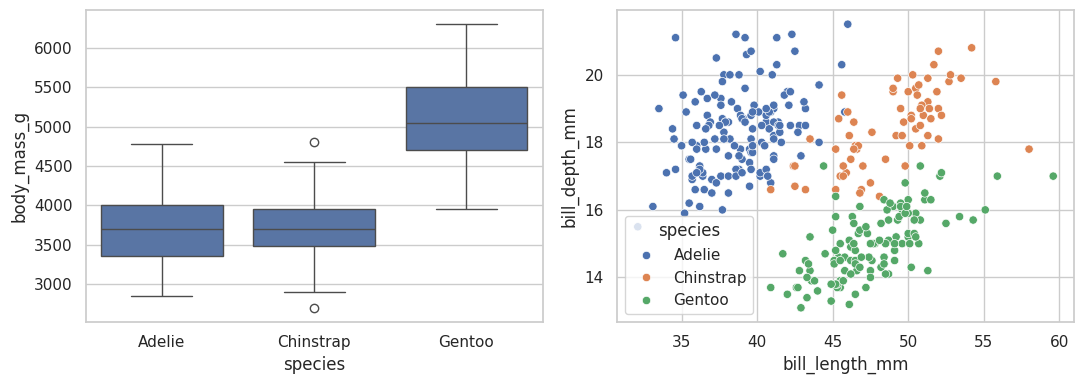

In [ ]:

pen = sns.load_dataset('penguins')

# 1. Drop rows with missing values
pen.dropna(inplace=True)

# 2. Convert 'island' to a categorical type
pen['island'] = pen['island'].astype('category')

# 2. Pairplot coloured by 'species'
sns.pairplot(pen, hue='species')
plt.show()

#

# 3. 1x2 subplot: boxplot (left) + scatter (right)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=pen, x='species', y='body_mass_g', ax=axes[0])
sns.scatterplot(data=pen, x='bill_length_mm', y='bill_depth_mm', hue='species', ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:

Xb, yb = load_breast_cancer(return_X_y=True)
print('Breast cancer data:', Xb.shape)

# 1. train_test_split
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.2, random_state=42)

#

# 2. Build a Pipeline (StandardScaler + a classifier)
pipe_lr = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(random_state=42))])
# 3. Fit and print the test accuracy
pipe_lr.fit(Xb_train, yb_train)
print('Test accuracy:', pipe_lr.score(Xb_test, yb_test))

Breast cancer data: (569, 30)
Test accuracy: 0.9736842105263158


In [ ]:
# 1. load
df=sns.load_dataset('iris')
df
#Separate features X and target species; encode the target to numbers.
X = df.drop(columns='species').values
y = df['species'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))
print('accuracy:', round(acc, 3))
 #3. split   4. model   5. output (print accuracy)

accuracy: 1.0


##PROBABILITY & STATISTICS##


 LAB EXERCISE 1 — Classify the columns
Print the list of numerical columns and the list of categorical columns.
For a numerical column (e.g. tip), print its mean.
For a categorical column (e.g. sex), print its value counts.

In [2]:
# 1. Numerical vs categorical columns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()
print('Numerical columns:', df.select_dtypes(include='number').columns.tolist())
print('Categorical columns:', df.select_dtypes(include='category').columns.tolist())

# 2. Mean of a numerical column (tip)
print('Mean of tip:', df['tip'].mean())

# 3. Value counts of a categorical column (sex)
print('Value counts of sex:\n', df['sex'].value_counts())

Loaded tips dataset: (244, 7)
Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']
Mean of tip: 2.99827868852459
Value counts of sex:
 sex
Male      157
Female     87
Name: count, dtype: int64


Mean: 2.99827868852459
Median: 2.9
Mode: 0    2.0
Name: tip, dtype: float64
Mean > Median: True


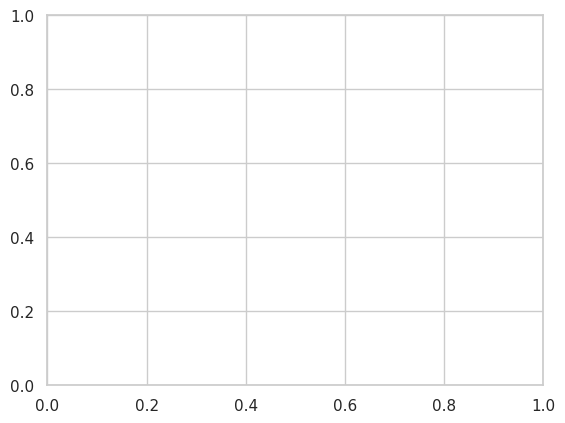

In [3]:
tip = df['tip']

# 1. mean, median, mode
print('Mean:', tip.mean())
print('Median:', tip.median())
print('Mode:', tip.mode())

#

# 2. mean > median ?
print('Mean > Median:', tip.mean() > tip.median())

# 3. histogram with mean & median lines (reuse the pattern from 2B)
fig, ax = plt.subplots()

Mean   : 19.79
Median : 17.8
Mode   : 13.42
mean > median ? True -> right-skewed


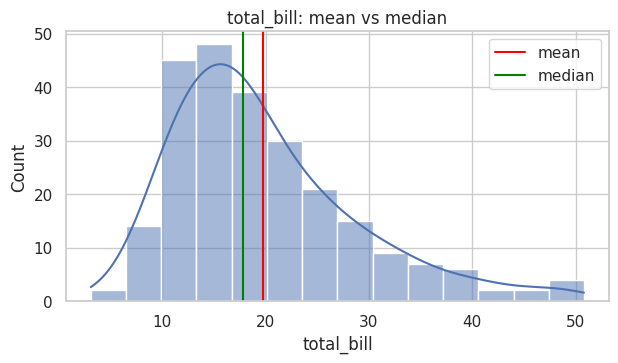

In [4]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean: 2.99827868852459
Median: 2.9
Mode: 0    2.0
Name: tip, dtype: float64
Mean > Median: True


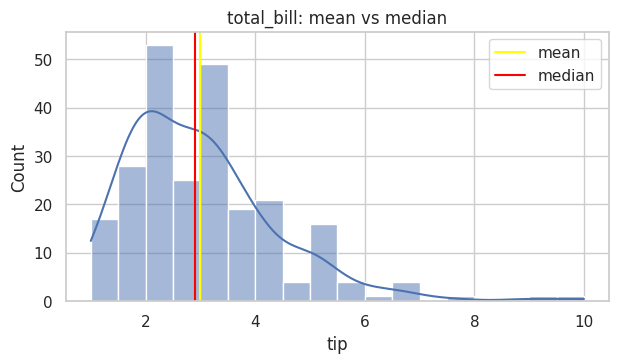

In [7]:
tip = df['tip']

# 1. mean, median, mode
print('Mean:', tip.mean())
print('Median:', tip.median())
print('Mode:', tip.mode())


# 2. mean > median ?
print('Mean > Median:', tip.mean() > tip.median())

# 3. histogram with mean & median lines (reuse the pattern from 2B)
plt.figure(figsize=(7, 3.5))
sns.histplot(tip, kde=True)
plt.axvline(tip.mean(),   color='yellow',   label='mean')
plt.axvline(tip.median(), color='red', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()


In [8]:

tip = df['tip']

# 1. range, variance, std
print('Range:', tip.max() - tip.min())
print('Variance:', tip.var())
print('Std:', tip.std())

#

# 2. Q1, Q3, IQR
print('Q1:', tip.quantile(0.25))
print('Q3:', tip.quantile(0.75))
print('IQR:', tip.quantile(0.75) - tip.quantile(0.25))

#

# 3. Most robust measure of spread = ?   (write your answer here)

Range: 9.0
Variance: 1.9144546380624725
Std: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


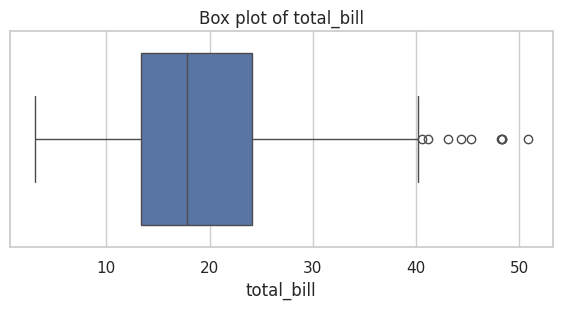

In [9]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

Min: 1.0
Q1: 2.0
Median: 2.9
Q3: 3.5625
Max: 10.0
Skewness: 1.4654510370979401


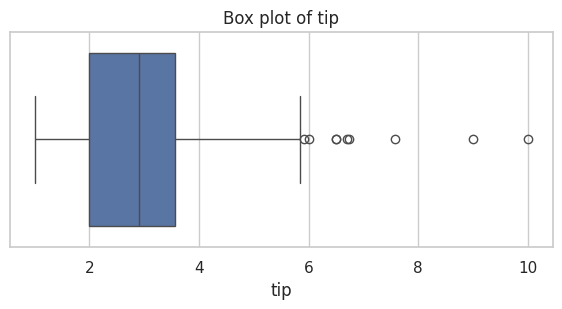

In [10]:
tip = df['tip']

# 1. five-number summary
print('Min:', tip.min())
print('Q1:', tip.quantile(0.25))
print('Median:', tip.median())
print('Q3:', tip.quantile(0.75))
print('Max:', tip.max())

#

# 2. skewness (+ comment on the direction of the lean)
print('Skewness:', tip.skew())

#

# 3. box plot of tip
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['tip'])
plt.title('Box plot of tip'); plt.show()


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


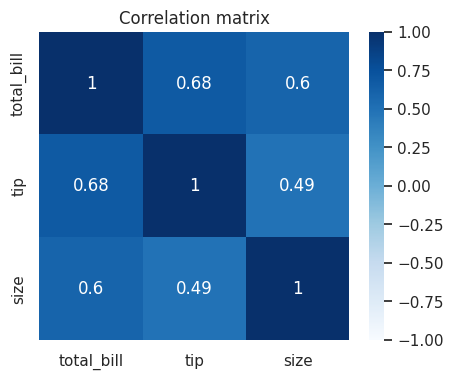

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [11]:
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()
df.describe()

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


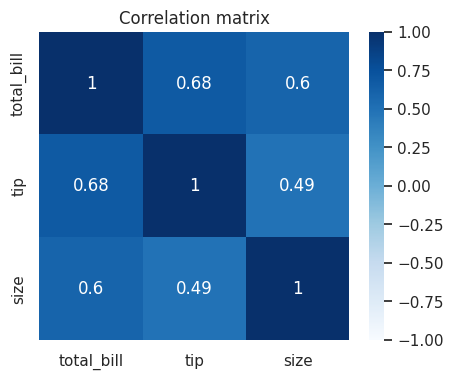

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. correlation matrix (rounded)
print(df.corr(numeric_only=True).round(2))
# 2. heatmap of the correlation matrix
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

# 3. df.describe() + 3 insights as comments
df.describe()